## Эксперимент 1. Классические модели

### Скачиваем данные

In [2]:
import pandas as pd
import numpy as np

model_data = pd.read_parquet("model_data.parquet")

print(model_data.shape)
model_data.head()

(1000000, 32)


,secret_id,max_turnover,max_turnover_clipped,log_target,log_income,all_bki_current_pmt,all_tinkoff_current_pmt,payment_to_income,payment_bki_to_income,payment_tkf_to_income,...,income_x_transaction_is_null,annual_revenue_is_null,vital_business_flg_is_null,risk_flg,phoenix_reject_flg,fns_status_problems_flg,vital_business_flg,okved_cluster,log_income_bucket,company_age_bucket
0,898a8b57faca0feb7e0ee11de6245af1,1.051667e+06,1.051667e+06,13.865888,13.332971,71477.0080,70040.0,0.229284,0.115806,0.113478,...,1,1,0,0,0,0,0.0,1,"(13.294, 20.724]",13-36
1,6c2f92f34b1ee3858a18421ebcede90b,4.267417e+06,4.267417e+06,15.266519,11.572486,37087.4035,13800.0,0.479455,0.349433,0.130022,...,1,0,0,0,0,0,0.0,2,"(11.488, 11.668]",85-180
2,ce0d5b0651e61d30282c260093893e7f,9.024167e+05,9.024167e+05,13.712833,11.630717,0.0000,0.0,0.000000,0.000000,0.000000,...,1,0,1,0,0,0,NaN,2,"(11.488, 11.668]",180+
3,a8e7c44015a356cc7bea31abcf759225,5.000000e+04,5.000000e+04,10.819798,12.997179,5546.7200,42180.0,0.108183,0.012573,0.095610,...,1,1,0,0,0,0,0.0,1,"(12.785, 13.294]",180+
4,3b43cc8fd5fe16200a62a84916a0ebd4,2.363054e+06,2.363054e+06,14.675466,12.034638,45451.9000,0.0,0.269760,0.269760,0.000000,...,0,1,0,0,0,0,0.0,2,"(11.949, 12.127]",85-180


### Подготовка данных и базовые проверки корректности

In [3]:
pd.set_option('display.float_format', '{:.2f}'.format)
model_data.dtypes

,0
secret_id,object
max_turnover,float64
max_turnover_clipped,float64
log_target,float64
log_income,float64
all_bki_current_pmt,float64
all_tinkoff_current_pmt,float64
payment_to_income,float64
payment_bki_to_income,float64
payment_tkf_to_income,float64


In [4]:
model_data.isnull().mean().sort_values(ascending=False)

,0
business_signal,0.76
transactions_to_income,0.76
transaction_amt,0.76
transaction_cnt,0.76
vital_business_flg,0.18
all_tinkoff_current_pmt,0.00
all_bki_current_pmt,0.00
company_age,0.00
payment_to_income,0.00
log_income,0.00


Фиксируем признаки для обучения и сегментации

In [5]:
ml_features = [
    "log_income",

    "all_bki_current_pmt",
    "all_tinkoff_current_pmt",
    "payment_to_income",
    "payment_bki_to_income",
    "payment_tkf_to_income",

    "transaction_amt",
    "transaction_cnt",
    "avg_transaction",
    "business_signal",
    "transactions_to_income",

    "company_age",
    "ip_flg",

    "transaction_amt_is_null",
    "transaction_cnt_is_null",
    "pred_transaction_amt_is_null",
    "business_signal_is_null",
    "transactions_to_income_is_null",
    "income_x_transaction_is_null",
    "annual_revenue_is_null",
    "vital_business_flg_is_null",

    "risk_flg",
    "phoenix_reject_flg",
    "fns_status_problems_flg",
    "vital_business_flg",

    "okved_cluster"
]

Формируем признаки для сегментации:
* имеют ограниченное множество значений для стабилизации предсказаний
* доступны для всех компаний

In [6]:
segment_cols = [
    "log_income_bucket",
    "ip_flg",
    "company_age_bucket",
    "transaction_amt_is_null",
    "okved_cluster"
]

Разбивка на train/test

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
target = "log_target"
groups = model_data["secret_id"]

In [13]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        model_data,
        model_data[target],
        groups=groups
    )
)

train = model_data.iloc[train_idx].copy()
test = model_data.iloc[test_idx].copy()

print(train.shape, test.shape)

(800380, 32) (199620, 32)


Проверка, что нет клиентов, которые одновременно попали в train и test

In [15]:
train_ids = set(train["secret_id"])
test_ids = set(test["secret_id"])

len(train_ids & test_ids)

0

### Сегментно-ориентированный алгоритм

Создаем таблицу с разбивкой по сегментам

In [11]:
global_pred = train[target].median()

segment_table = (
    train
    .groupby(segment_cols, observed=True)[target]
    .agg(
        segment_pred="median",
        segment_size="size"
    )
    .reset_index()
)

segment_table.head()

,log_income_bucket,ip_flg,company_age_bucket,transaction_amt_is_null,okved_cluster,segment_pred,segment_size
0,"(0.692, 11.488]",0,0-12,0,3,11.31,2
1,"(0.692, 11.488]",0,0-12,1,3,0.00,17
2,"(0.692, 11.488]",0,13-36,0,1,16.86,7
3,"(0.692, 11.488]",0,13-36,0,2,5.81,2
4,"(0.692, 11.488]",0,13-36,0,3,0.00,3


In [16]:
test_pred = test.merge(
    segment_table,
    on=segment_cols,
    how="left"
)

test_pred["segment_pred"] = test_pred["segment_pred"].fillna(global_pred)

Предсказания на тестовой выборке:

In [ ]:
y_true_log = test_pred[target].values
y_pred_log = test_pred["segment_pred"].values

y_true = np.expm1(y_true_log)
y_pred = np.expm1(y_pred_log)

mae_log = mean_absolute_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
r2_log = r2_score(y_true_log, y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

eps = 1

over_15 = (
    y_pred > 1.5 * np.maximum(y_true, eps)
).mean()

under_15 = (
    y_pred < y_true / 1.5
).mean()

print("Segment baseline metrics in log-space")
print(f"MAE log:  {mae_log:.4f}")
print(f"RMSE log: {rmse_log:.4f}")
print(f"R2 log:   {r2_log:.4f}")

print("\nSegment baseline metrics in original scale")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

print("\nBusiness metrics")
print(f"Overestimation > 1.5x:  {over_15:.2%}")
print(f"Underestimation > 1.5x: {under_15:.2%}")

Segment baseline metrics in log-space
MAE log:  4.4251
RMSE log: 6.7690
R2 log:   -0.0400

Segment baseline metrics in original scale
MAE:  1,923,724.59
RMSE: 8,006,394.73

Business metrics
Overestimation > 1.5x:  31.12%
Underestimation > 1.5x: 40.73%


Сравнение распределений

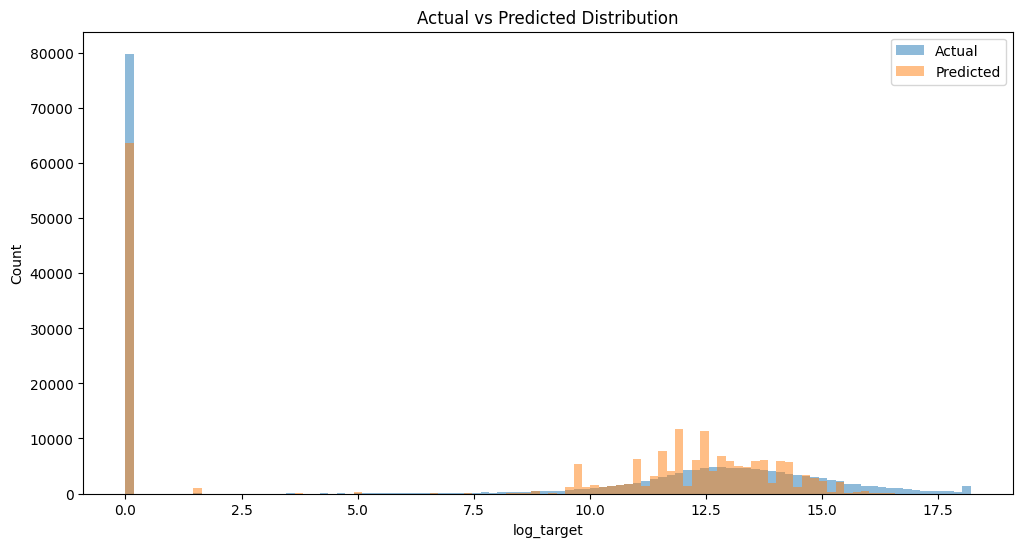

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.hist(
    y_true_log,
    bins=100,
    alpha=0.5,
    label="Actual"
)

plt.hist(
    y_pred_log,
    bins=100,
    alpha=0.5,
    label="Predicted"
)

plt.xlabel("log_target")
plt.ylabel("Count")
plt.title("Actual vs Predicted Distribution")
plt.legend()

plt.show()

### Функции для построения графиков

1. Сравнение предсказаний и реальных значений (scatterplot)

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, model_name="Model", alpha=0.05):
    plt.figure(figsize=(7, 7))
    plt.scatter(y_true, y_pred, alpha=alpha)

    min_val = min(np.min(y_true), np.min(y_pred))

    max_val = max(np.max(y_true), np.max(y_pred))

    plt.plot([min_val, max_val], [min_val, max_val])

    plt.xlabel("Actual log_target")
    plt.ylabel("Predicted log_target")

    plt.title(f"{model_name}: Actual vs Predicted")
    plt.show()


2. Сравнение распределений метрики $\hat{y}$ и y.

In [18]:
def plot_prediction_distribution(y_true, y_pred, model_name="Model", bins=100):
    plt.figure(figsize=(12, 6))

    plt.hist(y_true, bins=bins, alpha=0.5, label="Actual")

    plt.hist(y_pred, bins=bins, alpha=0.5, label="Predicted")

    plt.xlabel("log_target")
    plt.ylabel("Count")

    plt.title(f"{model_name}: Prediction Distribution")

    plt.legend()
    plt.show()

3. Сравнение распределений метрики $\hat{y}$ и y при $\hat{y}$ > treshold

In [19]:
def plot_nonzero_distribution(y_true, y_pred=None, model_name="Model", bins=100, min_turnover=1000):
    threshold = np.log1p(min_turnover)
    true_mask = y_true > threshold
    plt.figure(figsize=(12, 6))

    # actual distribution
    plt.hist(y_true[true_mask], bins=bins, alpha=0.5, label="Actual non-zero")

    # predicted distribution
    if y_pred is not None:
        pred_mask = y_pred > threshold
        plt.hist(y_pred[pred_mask], bins=bins, alpha=0.5, label="Predicted non-zero")

    plt.xlabel("log_target")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Non-zero Turnover Distribution")

    plt.legend()
    plt.show()

4. Сравнение распределений остатков $y - \hat{y}$

In [20]:
def plot_residual_distribution(y_true, y_pred, model_name="Model", bins=100):
    residuals = y_true - y_pred
    plt.figure(figsize=(12, 6))
    plt.hist(residuals, bins=bins)

    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.title(f"{model_name}: Residual Distribution")

    plt.show()

### ML-модели

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    RobustScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#### 1. Линейная регрессия с MSE

Выбираем фичи, коррелирующие с таргетом по итогам EDA. При этом исключим признаки, у которых наблюдается мультиколлинеарность - то есть они сильно коррелируют друг с другом.

In [22]:
linear_features = [
    "log_income",
    "all_bki_current_pmt",
    "all_tinkoff_current_pmt",
    "payment_to_income",
    "transaction_amt",
    "company_age",
    "ip_flg",
    "transaction_amt_is_null",
    "risk_flg",
    "okved_cluster"
]

Сплит на train/test

In [23]:
X_train = train[linear_features].copy()
X_test = test[linear_features].copy()

y_train = train["log_target"].copy()
y_test = test["log_target"].copy()

In [24]:
# Выделяем категориальные и численные признаки
categorical_cols = [
    "okved_cluster"
]

numeric_cols = [
    col for col in linear_features
    if col not in categorical_cols
]

Собираем пайплайн обучения

In [25]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [26]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

Обучение модели

In [ ]:
linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['log_income',
                                                   'all_bki_current_pmt',
                                                   'all_tinkoff_current_pmt',
                                                   'payment_to_income',
                                                   'transaction_amt',
                                                   'company_age', 'ip_flg',
                                                   'transaction_amt_is_null',
                                                   'risk_flg']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['okved_cluster'])])),
                ('regressor', LinearRegression())])

Получение предсказаний и результатов

In [ ]:
y_pred_log_raw = linear_model.predict(X_test)

# добавляем обрезку сверху для ограничения максимального предсказания
upper_pred_log = model_data["log_target"].quantile(0.999)

y_pred_log = np.clip(
    y_pred_log_raw,
    0,
    upper_pred_log
)

y_true_log = y_test.values

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

In [ ]:
mae_log = mean_absolute_error(
    y_true_log,
    y_pred_log
)

rmse_log = np.sqrt(
    mean_squared_error(
        y_true_log,
        y_pred_log
    )
)

r2_log = r2_score(
    y_true_log,
    y_pred_log
)

mae = mean_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

eps = 1

over_15 = (
    y_pred > 1.5 * np.maximum(y_true, eps)
).mean()

under_15 = (
    y_pred < y_true / 1.5
).mean()

print("LinearRegression metrics in log-space")
print(f"MAE log:  {mae_log:.4f}")
print(f"RMSE log: {rmse_log:.4f}")
print(f"R2 log:   {r2_log:.4f}")

print("\nLinearRegression metrics in original scale")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

print("\nBusiness metrics")
print(f"Overestimation > 1.5x:  {over_15:.2%}")
print(f"Underestimation > 1.5x: {under_15:.2%}")

LinearRegression metrics in log-space
MAE log:  5.2887
RMSE log: 5.8796
R2 log:   0.2153

LinearRegression metrics in original scale
MAE:  2,129,863.88
RMSE: 8,643,063.48

Business metrics
Overestimation > 1.5x:  43.63%
Underestimation > 1.5x: 54.51%


Графики:

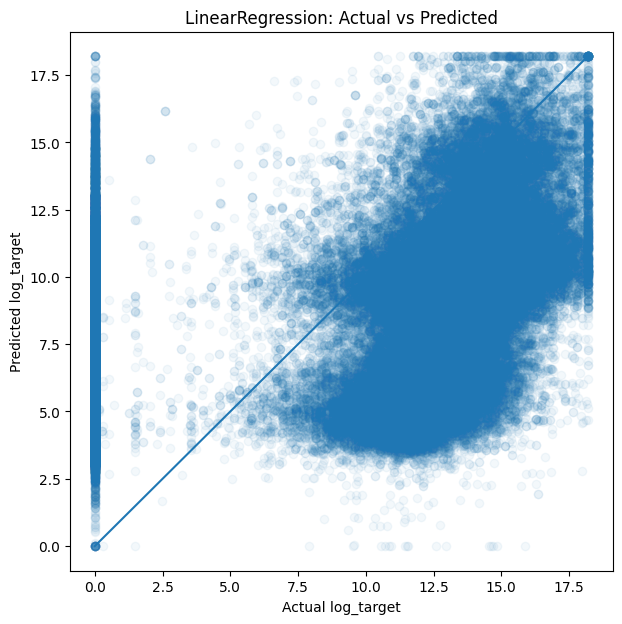

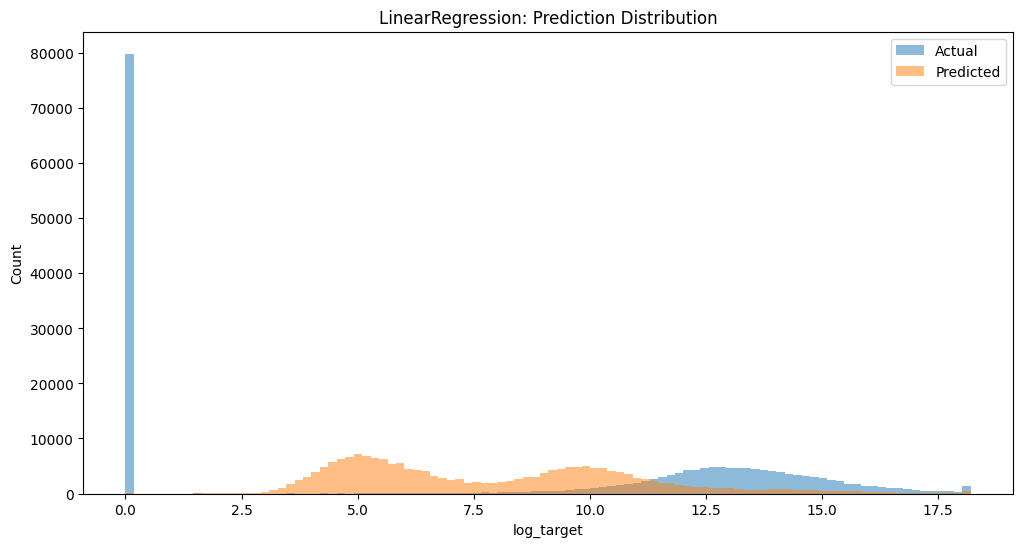

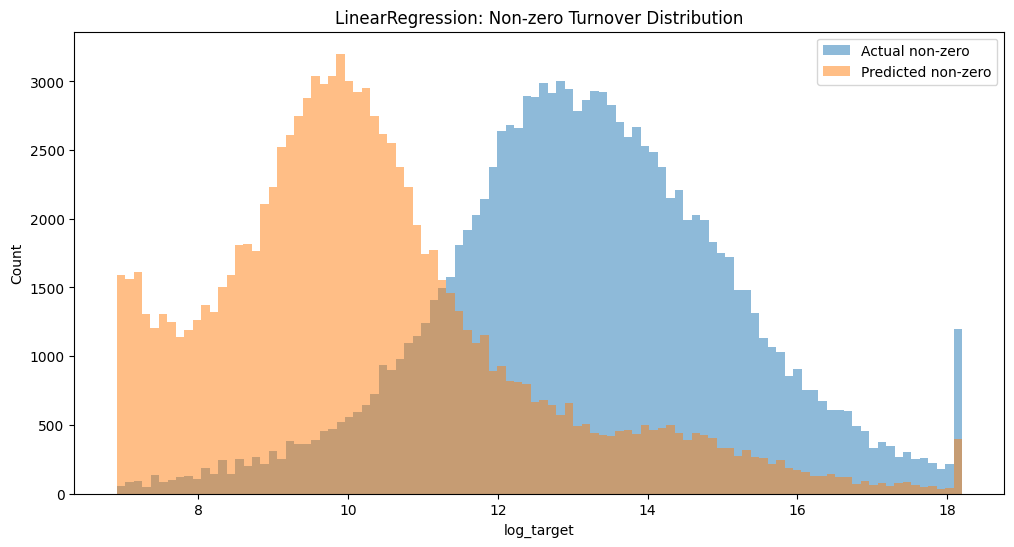

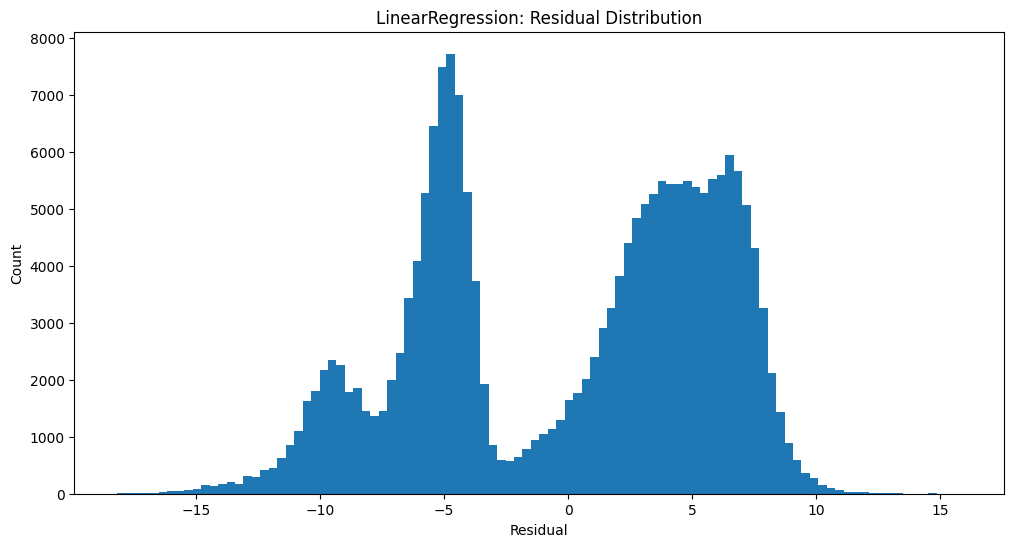

In [ ]:
plot_actual_vs_predicted(
    y_true_log,
    y_pred_log,
    model_name="LinearRegression"
)

plot_prediction_distribution(
    y_true_log,
    y_pred_log,
    model_name="LinearRegression"
)

plot_nonzero_distribution(
    y_true_log,
    y_pred_log,
    model_name="LinearRegression",
    min_turnover=1000
)

plot_residual_distribution(
    y_true_log,
    y_pred_log,
    model_name="LinearRegression"
)


#### 2. Линейная регрессия с Huberloss

In [27]:
from sklearn.linear_model import HuberRegressor

huber_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", HuberRegressor(
            epsilon=1.35,
            alpha=0.0001,
            max_iter=1000
        ))
    ]
)

In [ ]:
huber_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['log_income',
                                                   'all_bki_current_pmt',
                                                   'all_tinkoff_current_pmt',
                                                   'payment_to_income',
                                                   'transaction_amt',
                                                   'company_age', 'ip_flg',
                                                   'transaction_amt_is_null',
                                                   'risk_flg']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['okved_cluster'])])),
                ('regressor', HuberRegressor(max_iter=1000))])

In [ ]:
y_pred_log_raw = huber_model.predict(X_test)

upper_pred_log = model_data["log_target"].quantile(0.999)

y_pred_log = np.clip(
    y_pred_log_raw,
    0,
    upper_pred_log
)

y_true_log = y_test.values

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

In [ ]:
mae_log = mean_absolute_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
r2_log = r2_score(y_true_log, y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

eps = 1

over_15 = (
    y_pred > 1.5 * np.maximum(y_true, eps)
).mean()

under_15 = (
    y_pred < y_true / 1.5
).mean()

print("HuberRegressor metrics in log-space")
print(f"MAE log:  {mae_log:.4f}")
print(f"RMSE log: {rmse_log:.4f}")
print(f"R2 log:   {r2_log:.4f}")

print("\nHuberRegressor metrics in original scale")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

print("\nBusiness metrics")
print(f"Overestimation > 1.5x:  {over_15:.2%}")
print(f"Underestimation > 1.5x: {under_15:.2%}")

print("\nRaw prediction distribution before clipping")
print(f"min: {y_pred_log_raw.min():.4f}")
print(f"max: {y_pred_log_raw.max():.4f}")
print(
    np.percentile(
        y_pred_log_raw,
        [50, 90, 95, 99, 99.9, 99.99]
    )
)

HuberRegressor metrics in log-space
MAE log:  7.8775
RMSE log: 10.2959
R2 log:   -1.4061

HuberRegressor metrics in original scale
MAE:  2,035,398.26
RMSE: 8,418,680.78

Business metrics
Overestimation > 1.5x:  0.00%
Underestimation > 1.5x: 59.99%

Raw prediction distribution before clipping
min: -0.0057
max: 22.9390
[1.32330550e-10 3.28636098e-03 2.15426228e-02 1.07506439e-01
 7.21409264e-01 6.42715411e+00]


Графики

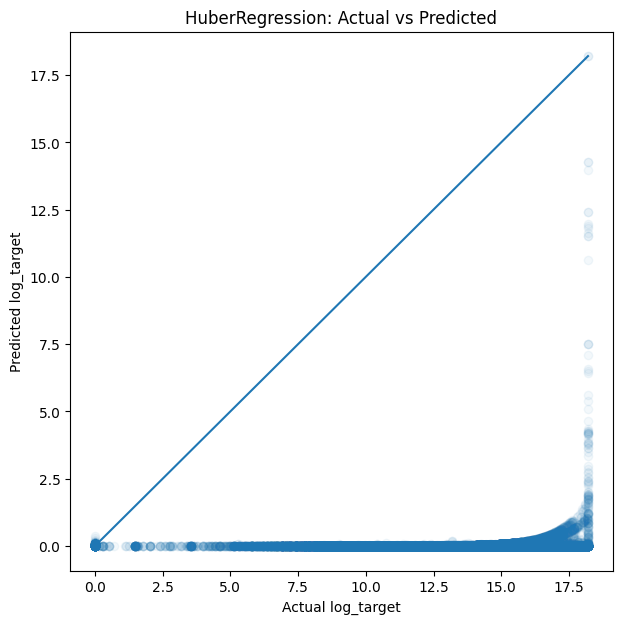

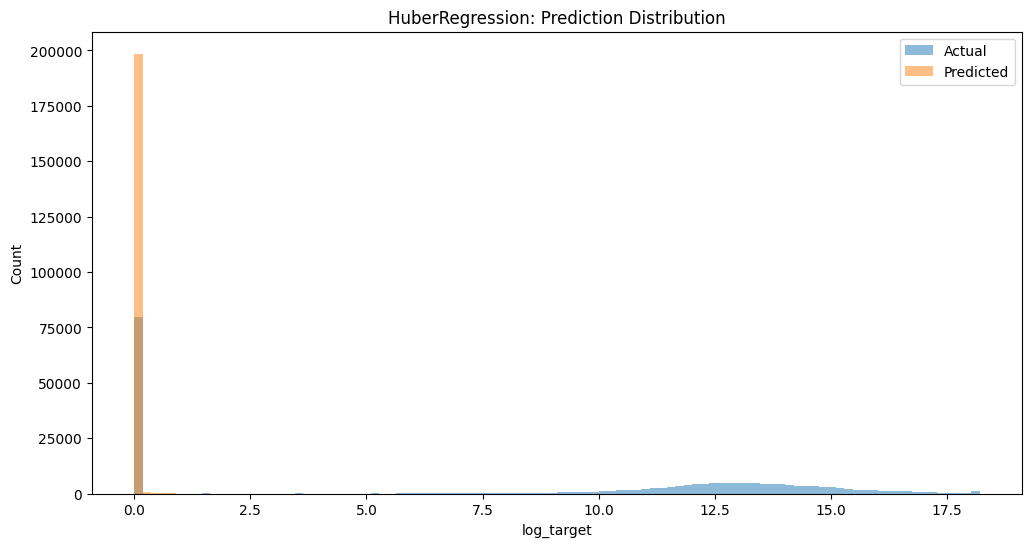

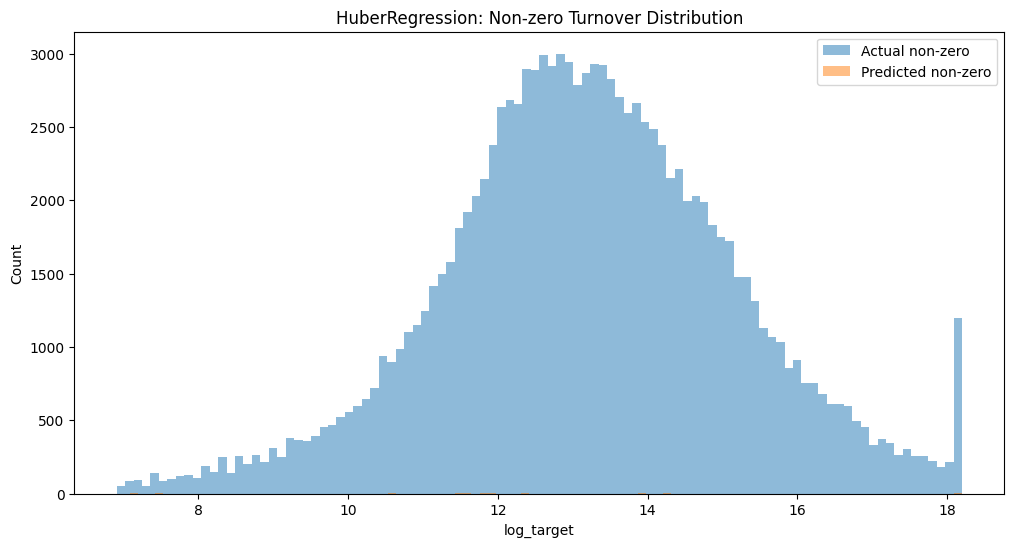

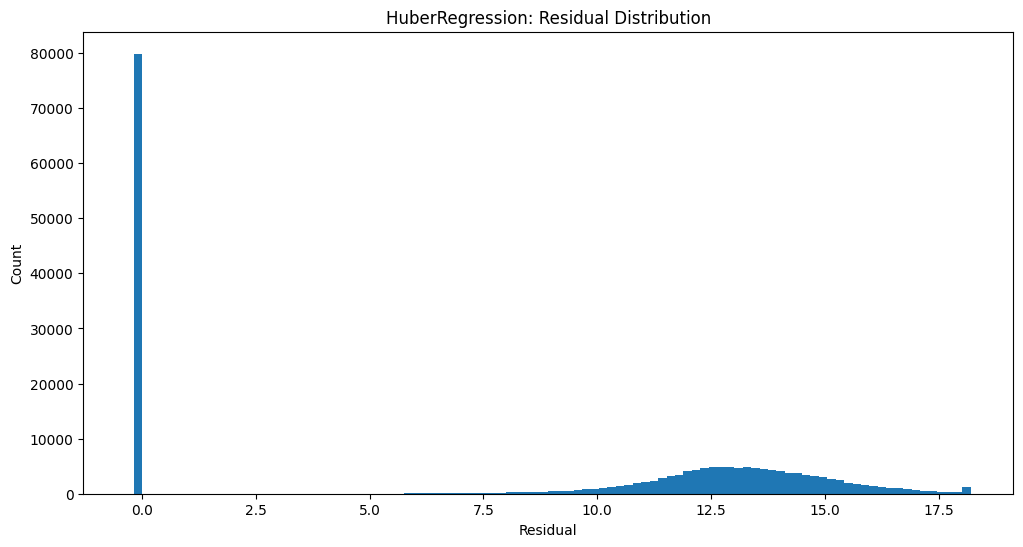

In [ ]:
plot_actual_vs_predicted(
    y_true_log,
    y_pred_log,
    model_name="HuberRegression"
)

plot_prediction_distribution(
    y_true_log,
    y_pred_log,
    model_name="HuberRegression"
)

plot_nonzero_distribution(
    y_true_log,
    y_pred_log,
    model_name="HuberRegression",
    min_turnover=1000
)

plot_residual_distribution(
    y_true_log,
    y_pred_log,
    model_name="HuberRegression"
)


Как мы видим, из-за особенности функции потерь (при большом отклонении от таргета ошибка выраждается в MAE), большая часть предсказаний имеет значение около нуля. В связи с этим, данные параметры неоптимальны для решения задачи.

Проверим гипотезу, что более оптимальные параметры позволят снизить значение ошибки и увеличить $R^2$

In [28]:
train_groups = train["secret_id"]
# внутри train делаем train/val split тоже по secret_id
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=43
)
inner_train_idx, val_idx = next(gss_val.split(X_train,y_train,groups=train_groups))

X_inner_train = X_train.iloc[inner_train_idx].copy()
y_inner_train = y_train.iloc[inner_train_idx].copy()
X_val = X_train.iloc[val_idx].copy()
y_val = y_train.iloc[val_idx].copy()

Кросс-валидация

In [ ]:
epsilons = [1.1, 1.35, 1.75, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0, 10.0]
alphas = [0.00001, 0.0001, 0.001]

results = []
upper_pred_log = model_data["log_target"].quantile(0.995)
for epsilon in epsilons:
    for alpha in alphas:
        model = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("regressor", HuberRegressor(
                    epsilon=epsilon,
                    alpha=alpha,
                    max_iter=1000
                ))
            ]
        )

        model.fit(X_inner_train, y_inner_train)
        y_val_pred_raw = model.predict(X_val)
        y_val_pred = np.clip(y_val_pred_raw, 0, upper_pred_log)

        mae_log = mean_absolute_error(y_val, y_val_pred)
        rmse_log = np.sqrt(mean_squared_error(y_val, y_val_pred))
        r2_log = r2_score(y_val, y_val_pred)

        y_val_orig = np.expm1(y_val)
        y_pred_orig = np.expm1(y_val_pred)

        over_15 = (
            y_pred_orig > 1.5 * np.maximum(y_val_orig, 1)
        ).mean()

        under_15 = (
            y_pred_orig < y_val_orig / 1.5
        ).mean()

        results.append({
            "epsilon": epsilon,
            "alpha": alpha,
            "mae_log": mae_log,
            "rmse_log": rmse_log,
            "r2_log": r2_log,
            "over_15": over_15,
            "under_15": under_15,
            "pred_median": np.median(y_val_pred),
            "pred_p95": np.percentile(y_val_pred, 95),
            "pred_p99": np.percentile(y_val_pred, 99)
        })

huber_tuning_results = pd.DataFrame(results)

huber_tuning_results.sort_values("r2_log", ascending=False).head(10)

,epsilon,alpha,mae_log,rmse_log,r2_log,over_15,under_15,pred_median,pred_p95,pred_p99
19,4.00,0.00,6.31,7.05,-0.13,0.44,0.55,5.87,14.21,18.20
20,4.00,0.00,6.31,7.05,-0.13,0.44,0.55,5.87,14.21,18.20
18,4.00,0.00,6.31,7.05,-0.13,0.44,0.55,5.87,14.21,18.20
29,10.00,0.00,6.49,7.24,-0.19,0.42,0.57,4.77,11.56,18.20
28,10.00,0.00,6.79,7.70,-0.35,0.40,0.59,3.50,8.49,14.67
27,10.00,0.00,6.79,7.70,-0.35,0.40,0.59,3.50,8.49,14.67
16,3.00,0.00,7.85,10.25,-1.38,0.00,0.60,0.00,0.17,0.96
15,3.00,0.00,7.85,10.25,-1.38,0.00,0.60,0.00,0.17,0.96
17,3.00,0.00,7.85,10.25,-1.38,0.00,0.60,0.00,0.17,0.96
13,2.50,0.00,7.85,10.25,-1.38,0.00,0.60,0.00,0.17,0.96


Обучаем на лучших показателях:

In [ ]:
best_params = (
    huber_tuning_results
    .sort_values("r2_log", ascending=False)
    .iloc[0]
)

best_epsilon = best_params["epsilon"]
best_alpha = best_params["alpha"]

print(best_epsilon, best_alpha)

best_huber_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", HuberRegressor(
            epsilon=best_epsilon,
            alpha=best_alpha,
            max_iter=1000
        ))
    ]
)

best_huber_model.fit(X_train, y_train)

y_pred_log_raw = best_huber_model.predict(X_test)

y_pred_log = np.clip(
    y_pred_log_raw,
    0,
    upper_pred_log
)

y_true_log = y_test.values

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

mae_log = mean_absolute_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
r2_log = r2_score(y_true_log, y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

over_15 = (
    y_pred > 1.5 * np.maximum(y_true, 1)
).mean()

under_15 = (
    y_pred < y_true / 1.5
).mean()

print("Best HuberRegressor metrics in log-space")
print(f"epsilon: {best_epsilon}")
print(f"alpha:   {best_alpha}")
print(f"MAE log:  {mae_log:.4f}")
print(f"RMSE log: {rmse_log:.4f}")
print(f"R2 log:   {r2_log:.4f}")

print("\nBest HuberRegressor metrics in original scale")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

print("\nBusiness metrics")
print(f"Overestimation > 1.5x:  {over_15:.2%}")
print(f"Underestimation > 1.5x: {under_15:.2%}")

4.0 0.0001
Best HuberRegressor metrics in log-space
epsilon: 4.0
alpha:   0.0001
MAE log:  7.8776
RMSE log: 10.2959
R2 log:   -1.4062

Best HuberRegressor metrics in original scale
MAE:  2,035,401.30
RMSE: 8,418,709.30

Business metrics
Overestimation > 1.5x:  0.00%
Underestimation > 1.5x: 59.99%


Зависимость $R^2$ от $ɛ$

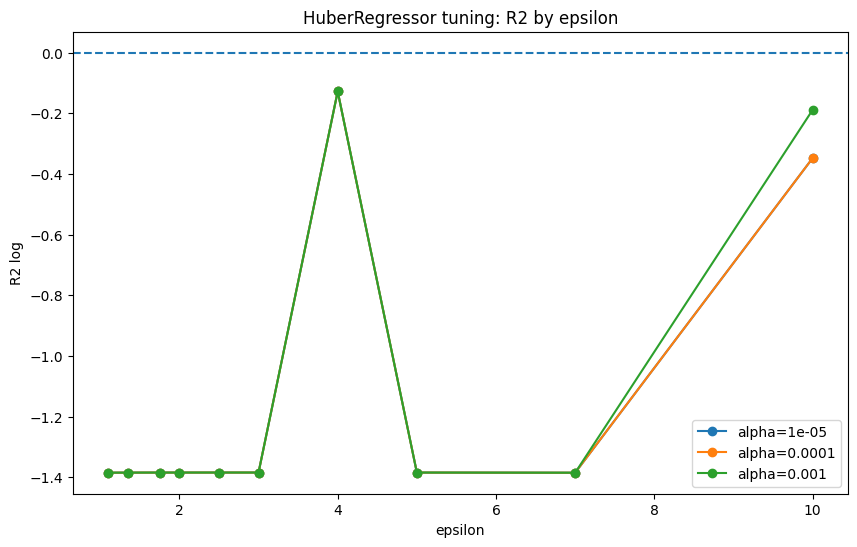

In [ ]:
import matplotlib.pyplot as plt

plot_df = (
    huber_tuning_results
    .sort_values("epsilon")
)

plt.figure(figsize=(10, 6))

for alpha in plot_df["alpha"].unique():
    subset = plot_df[plot_df["alpha"] == alpha]

    plt.plot(
        subset["epsilon"],
        subset["r2_log"],
        marker="o",
        label=f"alpha={alpha}"
    )

plt.axhline(0, linestyle="--")

plt.xlabel("epsilon")
plt.ylabel("R2 log")
plt.title("HuberRegressor tuning: R2 by epsilon")
plt.legend()

plt.show()

Подбор параметров не привел к значительному улучшению результатов, поэтому данная модель не является оптимальной для задачи.

#### 3. RandomForest

Обновляем список признаков - модель не чувствительна к мультиколлинеарности.

In [29]:
rf_features = [
    "log_income",

    "all_bki_current_pmt",
    "all_tinkoff_current_pmt",

    "payment_to_income",
    "payment_bki_to_income",
    "payment_tkf_to_income",

    "transaction_amt",
    "transaction_cnt",
    "avg_transaction",

    "business_signal",
    "transactions_to_income",

    "company_age",

    "ip_flg",

    "transaction_amt_is_null",
    "transaction_cnt_is_null",
    "pred_transaction_amt_is_null",

    "business_signal_is_null",
    "transactions_to_income_is_null",

    "risk_flg",
    "phoenix_reject_flg",
    "fns_status_problems_flg",

    "vital_business_flg",

    "okved_cluster"
]

Кодируем категориальные признаки - используем LabelEncoder (оптимально для RF) [[1]](https://www.geeksforgeeks.org/machine-learning/how-to-fit-categorical-data-types-for-random-forest-classification/?ysclid=mp1oa4phpm262390555)

In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import (GroupShuffleSplit, GroupKFold, RandomizedSearchCV)
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, make_scorer)

X_train_rf = train[rf_features].copy()
X_test_rf = test[rf_features].copy()
y_train_rf = train[target].copy().reset_index(drop=True)
y_test_rf = test[target].copy().reset_index(drop=True)

train_groups = train["secret_id"].copy().reset_index(drop=True)

In [32]:
categorical_cols = [
    "okved_cluster"
]

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train_rf[col] = le.fit_transform(X_train_rf[col].astype(str))
    X_test_rf[col] = X_test_rf[col].astype(str).map(dict(zip(le.classes_, le.transform(le.classes_))))
    X_test_rf[col] = X_test_rf[col].fillna(-1).astype(int)

    label_encoders[col] = le

Заполняем пустые значения медианой. При этом, оставляем флаги, которые означают, что в оригинальном датасете значение пропущено

In [ ]:
imputer = SimpleImputer(
    strategy="median"
)

X_train_rf = pd.DataFrame(
    imputer.fit_transform(X_train_rf),
    columns=X_train_rf.columns
).reset_index(drop=True)

X_test_rf = pd.DataFrame(
    imputer.transform(X_test_rf),
    columns=X_test_rf.columns
).reset_index(drop=True)

Создаем функцию для оценки результатов - используем далее при кросс-валидации

In [ ]:
def rmse_scorer(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true,y_pred))

scorer = make_scorer(
    rmse_scorer,
    greater_is_better=True
)

Создаем и параметры для подбора. Кросс-валидацию будем осуществлять на подвыборке тренировочного датасета (ввиду большого объема данных). При этом, исходное распределение данных сохраняется (лог-нормальное с такими же параметрами), поэтому можем утверждать, что с вероятностью $p → ∞ $ на всей выборке оптимальные гиперпараметры совпадут с полученными.

In [ ]:
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [ ]:
sample_pos = np.random.default_rng(42).choice(len(X_train_rf), size=200_000, replace=False)

X_train_rf_sample = X_train_rf.iloc[sample_pos]
y_train_rf_sample = y_train_rf.iloc[sample_pos]
groups_sample = train_groups.iloc[sample_pos]

In [ ]:
param_distributions = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [20, 50, 100],
    "min_samples_split": [50, 100],
    "max_features": ["sqrt", 0.5],
    "bootstrap": [True]
}

Кросс-валидация

In [ ]:
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter=8,
    scoring=scorer,
    cv=GroupKFold(n_splits=3),
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_search.fit(
    X_train_rf_sample,
    y_train_rf_sample,
    groups=groups_sample
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


RandomizedSearchCV(cv=GroupKFold(n_splits=3, random_state=None, shuffle=False),
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [8, 12, 16],
                                        'max_features': ['sqrt', 0.5],
                                        'min_samples_leaf': [20, 50, 100],
                                        'min_samples_split': [50, 100],
                                        'n_estimators': [100, 200]},
                   random_state=42,
                   scoring=make_scorer(rmse_scorer, response_method='predict'),
                   verbose=2)

Обучаем модель на лучших параметрах

In [ ]:
best_params = rf_search.best_params_

best_rf_model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_rf_model.fit(
    X_train_rf,
    y_train_rf
)

RandomForestRegressor(max_depth=16, max_features=0.5, min_samples_leaf=20,
                      min_samples_split=100, n_jobs=-1, random_state=42)

Предсказания

In [ ]:
y_pred_log_raw = best_rf_model.predict(X_test_rf)

upper_pred_log = model_data["log_target"].quantile(0.999)

y_pred_log = np.clip(
    y_pred_log_raw,
    0,
    upper_pred_log
)

y_true_log = y_test_rf.values

In [ ]:
# оригинальная шкала
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

Метрики:

In [ ]:
mae_log = mean_absolute_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
r2_log = r2_score(y_true_log, y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

over_15 = (
    y_pred > 1.5 * np.maximum(y_true, 1)
).mean()

under_15 = (
    y_pred < y_true / 1.5
).mean()

print("RandomForest metrics in log-space")
print(f"MAE log:  {mae_log:.4f}")
print(f"RMSE log: {rmse_log:.4f}")
print(f"R2 log:   {r2_log:.4f}")

print("\nRandomForest metrics in original scale")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

print("\nBusiness metrics")
print(f"Overestimation > 1.5x:  {over_15:.2%}")
print(f"Underestimation > 1.5x: {under_15:.2%}")

RandomForest metrics in log-space
MAE log:  4.5993
RMSE log: 5.4638
R2 log:   0.3224

RandomForest metrics in original scale
MAE:  1,685,809.14
RMSE: 7,746,256.35

Business metrics
Overestimation > 1.5x:  42.64%
Underestimation > 1.5x: 44.77%


Графики

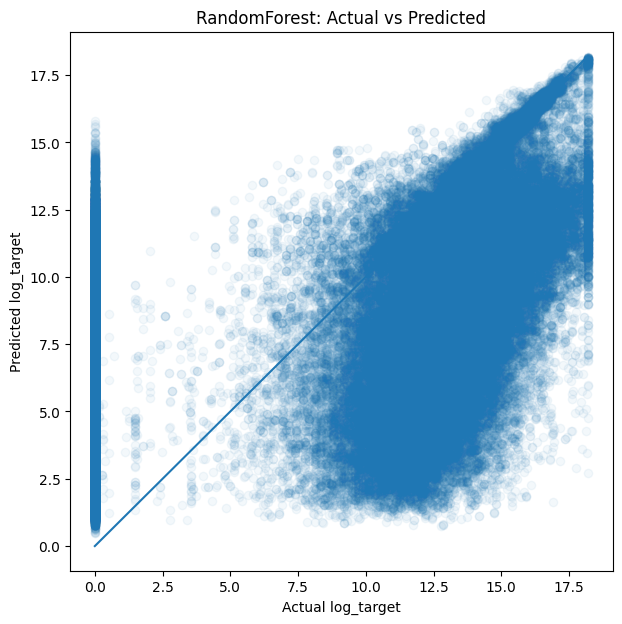

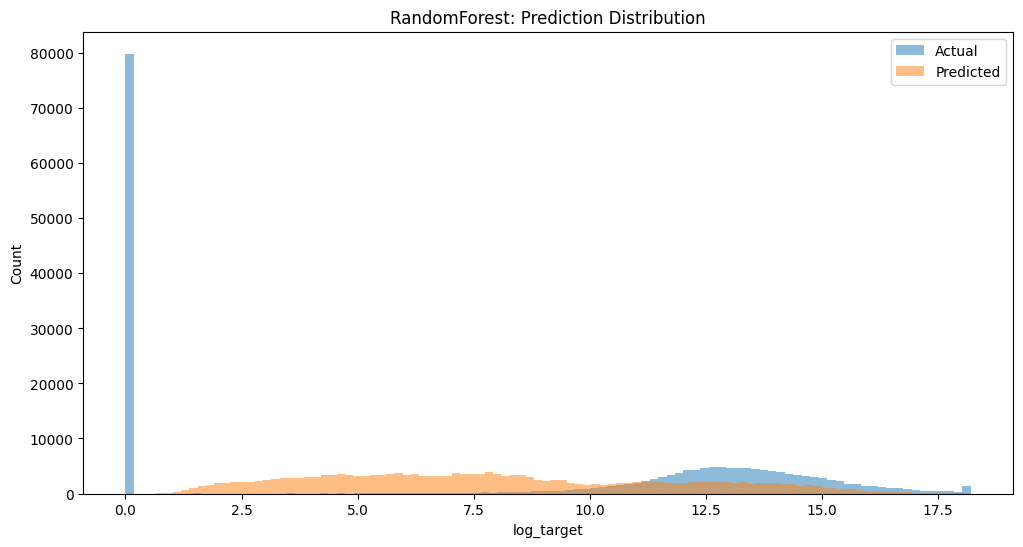

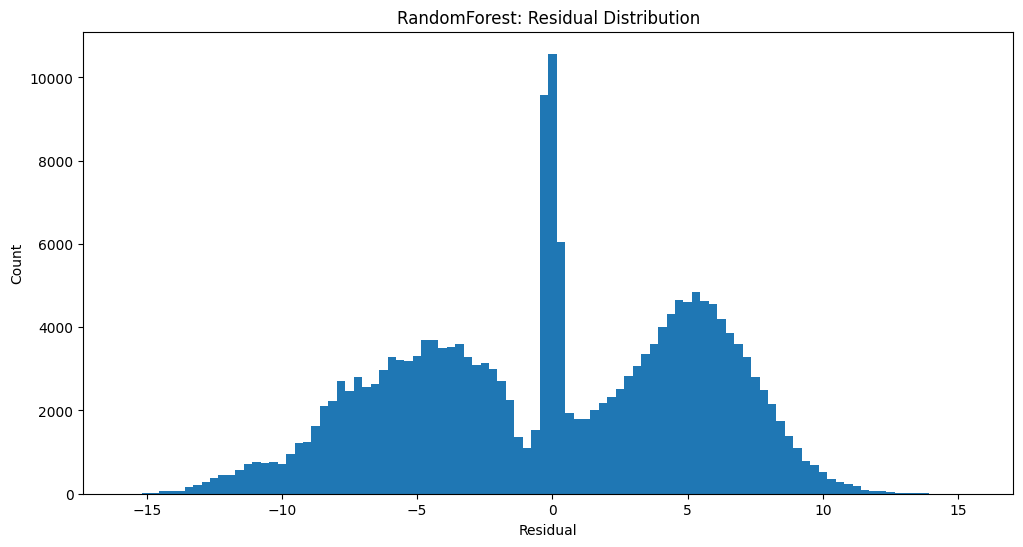

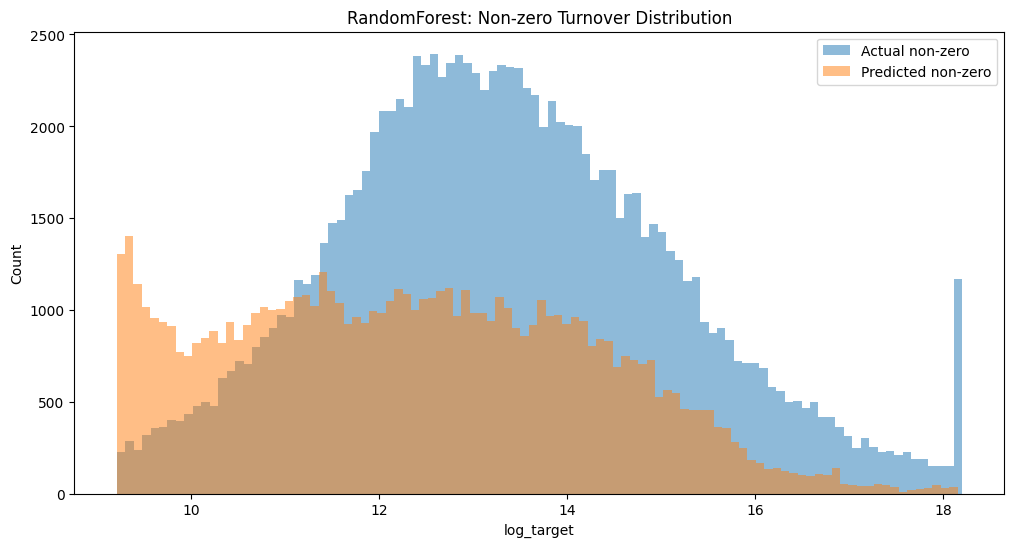

In [ ]:
plot_actual_vs_predicted(
    y_true_log,
    y_pred_log,
    model_name="RandomForest"
)

plot_prediction_distribution(
    y_true_log,
    y_pred_log,
    model_name="RandomForest"
)

plot_residual_distribution(
    y_true_log,
    y_pred_log,
    model_name="RandomForest"
)

plot_nonzero_distribution(
    y_true_log,
    y_pred_log,
    model_name="RandomForest",
    min_turnover=10000
)

Feature importance

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_train_rf.columns,
    "importance": best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
12,ip_flg,0.28
7,transaction_cnt,0.20
0,log_income,0.16
10,transactions_to_income,0.10
11,company_age,0.07
8,avg_transaction,0.05
6,transaction_amt,0.03
4,payment_bki_to_income,0.02
3,payment_to_income,0.02
2,all_tinkoff_current_pmt,0.02


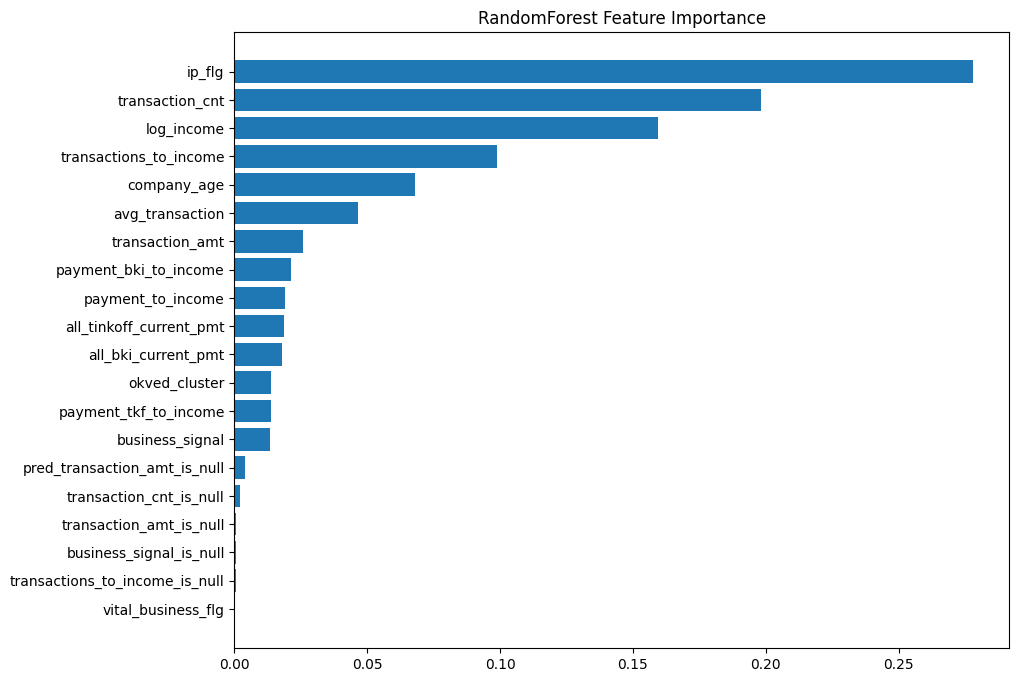

In [ ]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["feature"].head(20)[::-1],
    feature_importance["importance"].head(20)[::-1]
)

plt.title("RandomForest Feature Importance")
plt.show()

Выводы по данной модели:

1. Наиболее большой вес имеет разделение компаний на ИП/ООО. Это позволяет более четко определять оборот, поскольку у ИП:
    * другая бизнес-модель;
    * другой оборот;
    * транзакции физ. лица более схожи с реальными оборотами бизнеса.

2. Количество транзакций имеет больший вес, чем их сумма - предприниматели с большим количеством транзакций могут более активно вести бизнес независимо от их суммы

3. Доход физ. лица является важным признаком - подтверждает гипотезу о связи оборота и чистых доходов.

В сравнении с сегментным алгоритмом, RF лучше определяет variance (разброс), поскольку метрика $R^2$ имеет существенно более высокие значения.

#### 4. GradientBoosting

В рамках данной работы исследованы наиболее популярные модели градиентного бустинга - CatBoost, LightGBM и XGBoost.

In [33]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Признаки для обучения - используем те же, что и для RandomForest. Преобразуем категориальные признаки к строковому типу, чтобы дальнейший encoding выполнялся инструментами бустинга.

In [49]:
X_train = train[rf_features].copy()
X_test = test[rf_features].copy()
y_train = train[target].copy()
y_test = test[target].copy()

train_groups = train["secret_id"].reset_index(drop=True)

print(X_train.shape, X_test.shape)

(800380, 23) (199620, 23)


In [50]:
cat_features = [
    "ip_flg",
    "transaction_amt_is_null",
    "transaction_cnt_is_null",
    "pred_transaction_amt_is_null",
    "business_signal_is_null",
    "transactions_to_income_is_null",
    "risk_flg",
    "phoenix_reject_flg",
    "fns_status_problems_flg",
    "vital_business_flg",
    "okved_cluster"
]

for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

Сплит на train/validation/test

In [51]:
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=43
)

inner_train_idx, val_idx = next(
    gss_val.split(
        X_train,
        y_train,
        groups=train_groups
    )
)

X_inner_train = X_train.iloc[inner_train_idx].copy()
y_inner_train = y_train.iloc[inner_train_idx].copy()

X_val = X_train.iloc[val_idx].copy()
y_val = y_train.iloc[val_idx].copy()

print(X_inner_train.shape, X_val.shape)

(640385, 23) (159995, 23)


In [52]:
sample_size = 200_000

sample_pos = np.random.default_rng(42).choice(
    len(X_inner_train),
    size=min(sample_size, len(X_inner_train)),
    replace=False
)

X_inner_train_sample = X_inner_train.iloc[sample_pos].copy()
y_inner_train_sample = y_inner_train.iloc[sample_pos].copy()

Кросс-валидация на подвыборке:

In [53]:
# Формат для CatBoost
train_pool_sample = Pool(
    X_inner_train_sample,
    y_inner_train_sample,
    cat_features=cat_features
)

val_pool = Pool(
    X_val,
    y_val,
    cat_features=cat_features
)

In [54]:
# гиперпараметры
param_grid = [
    { "depth": 4, "learning_rate": 0.05, "l2_leaf_reg": 3, "iterations": 1000},
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 3, "iterations": 1000},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 5, "iterations": 1500},
    {"depth": 8, "learning_rate": 0.03, "l2_leaf_reg": 5, "iterations": 1500},
    {"depth": 8, "learning_rate": 0.02, "l2_leaf_reg": 10, "iterations": 2000}
]

In [ ]:
tuning_results = []

for params in param_grid:

    model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        verbose=False,
        early_stopping_rounds=100,
        **params
    )

    model.fit(
        train_pool_sample,
        eval_set=val_pool,
        use_best_model=True
    )

    y_val_pred = model.predict(val_pool)

    upper_pred_log = model_data["log_target"].quantile(0.999)

    y_val_pred = np.clip(
        y_val_pred,
        0,
        upper_pred_log
    )

    mae_log = mean_absolute_error(y_val, y_val_pred)
    rmse_log = np.sqrt(mean_squared_error(y_val, y_val_pred))
    r2_log = r2_score(y_val, y_val_pred)

    tuning_results.append({
        **params,
        "best_iteration": model.get_best_iteration(),
        "mae_log": mae_log,
        "rmse_log": rmse_log,
        "r2_log": r2_log
    })

catboost_tuning_results = pd.DataFrame(tuning_results)

catboost_tuning_results.sort_values(
    "r2_log",
    ascending=False
)

,depth,learning_rate,l2_leaf_reg,iterations,best_iteration,mae_log,rmse_log,r2_log
4,8,0.02,10,2000,1618,4.61,5.45,0.33
3,8,0.03,5,1500,852,4.61,5.45,0.33
2,6,0.03,5,1500,1390,4.62,5.45,0.33
1,6,0.05,3,1000,606,4.62,5.45,0.33
0,4,0.05,3,1000,984,4.64,5.45,0.32


In [ ]:
best_row = (
    catboost_tuning_results
    .sort_values("r2_log", ascending=False)
    .iloc[0]
)

best_params = {
    "depth": int(best_row["depth"]),
    "learning_rate": float(best_row["learning_rate"]),
    "l2_leaf_reg": float(best_row["l2_leaf_reg"]),
    "iterations": int(best_row["iterations"])
}

best_params

{'depth': 8, 'learning_rate': 0.02, 'l2_leaf_reg': 10.0, 'iterations': 2000}

Обучение

In [55]:
best_params = {
    "depth": 8,
    "learning_rate": 0.02,
    "l2_leaf_reg": 10.0,
    "iterations": 2000
}

In [56]:
train_full_pool = Pool(
    X_train,
    y_train,
    cat_features=cat_features
)

test_pool = Pool(
    X_test,
    y_test,
    cat_features=cat_features
)

catboost_model = CatBoostRegressor(
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100,
    **best_params
)

catboost_model.fit(
    train_full_pool
)

0:	learn: 6.5977504	total: 882ms	remaining: 29m 23s
100:	learn: 5.4999011	total: 1m 2s	remaining: 19m 39s
200:	learn: 5.4490411	total: 2m 3s	remaining: 18m 29s
300:	learn: 5.4363259	total: 3m 1s	remaining: 17m 4s
400:	learn: 5.4291851	total: 4m	remaining: 16m
500:	learn: 5.4239645	total: 4m 58s	remaining: 14m 52s
600:	learn: 5.4193950	total: 5m 57s	remaining: 13m 51s
700:	learn: 5.4152423	total: 6m 56s	remaining: 12m 52s
800:	learn: 5.4111088	total: 7m 56s	remaining: 11m 53s
900:	learn: 5.4066343	total: 8m 57s	remaining: 10m 55s
1000:	learn: 5.4031963	total: 9m 56s	remaining: 9m 55s
1100:	learn: 5.4000478	total: 10m 53s	remaining: 8m 53s
1200:	learn: 5.3967596	total: 11m 53s	remaining: 7m 54s
1300:	learn: 5.3936705	total: 12m 51s	remaining: 6m 54s
1400:	learn: 5.3908127	total: 13m 49s	remaining: 5m 54s
1500:	learn: 5.3878829	total: 14m 47s	remaining: 4m 54s
1600:	learn: 5.3849258	total: 15m 47s	remaining: 3m 56s
1700:	learn: 5.3821406	total: 16m 46s	remaining: 2m 56s
1800:	learn: 5.379

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=2000, l2_leaf_reg=10.0, learning_rate=0.02, loss_function='RMSE', random_seed=42, verbose=100)

Прогноз

In [57]:
y_pred_log_raw = catboost_model.predict(test_pool)

upper_pred_log = model_data["log_target"].quantile(0.999)

y_pred_log = np.clip(
    y_pred_log_raw,
    0,
    upper_pred_log
)

y_true_log = y_test.values

Метрики

In [58]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_true_log)

mae_log = mean_absolute_error(y_true_log, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
r2_log = r2_score(y_true_log, y_pred_log)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

over_15 = (
    y_pred > 1.5 * np.maximum(y_true, 1)
).mean()

under_15 = (
    y_pred < y_true / 1.5
).mean()

print("CatBoost metrics in log-space")
print(f"MAE log:  {mae_log:.4f}")
print(f"RMSE log: {rmse_log:.4f}")
print(f"R2 log:   {r2_log:.4f}")

print("\nCatBoost metrics in original scale")
print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

print("\nBusiness metrics")
print(f"Overestimation > 1.5x:  {over_15:.2%}")
print(f"Underestimation > 1.5x: {under_15:.2%}")

CatBoost metrics in log-space
MAE log:  4.5891
RMSE log: 5.4404
R2 log:   0.3282

CatBoost metrics in original scale
MAE:  1,717,633.65
RMSE: 7,764,755.09

Business metrics
Overestimation > 1.5x:  43.84%
Underestimation > 1.5x: 45.47%


In [60]:
catboost_model.save_model(
    "model.cbm"
)

In [59]:
import joblib

joblib.dump(
    catboost_model,
    "model.pkl"
)

['model.pkl']

Feature importance

In [63]:
feature_importance = pd.DataFrame({
    "feature": rf_features,
    "importance": catboost_model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
12,ip_flg,39.77
7,transaction_cnt,28.45
0,log_income,10.84
11,company_age,6.72
22,okved_cluster,2.37
4,payment_bki_to_income,2.15
2,all_tinkoff_current_pmt,1.72
6,transaction_amt,1.54
1,all_bki_current_pmt,1.49
3,payment_to_income,1.20


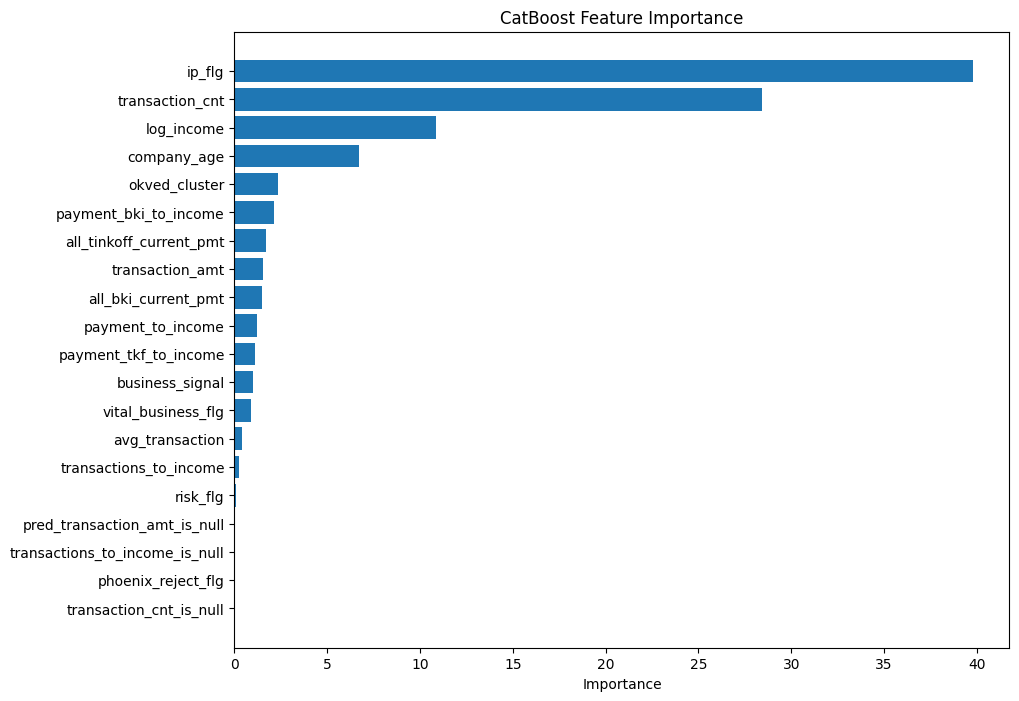

In [66]:
top_n = 20

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["feature"].head(top_n)[::-1],
    feature_importance["importance"].head(top_n)[::-1]
)

plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")

plt.show()

Графики:

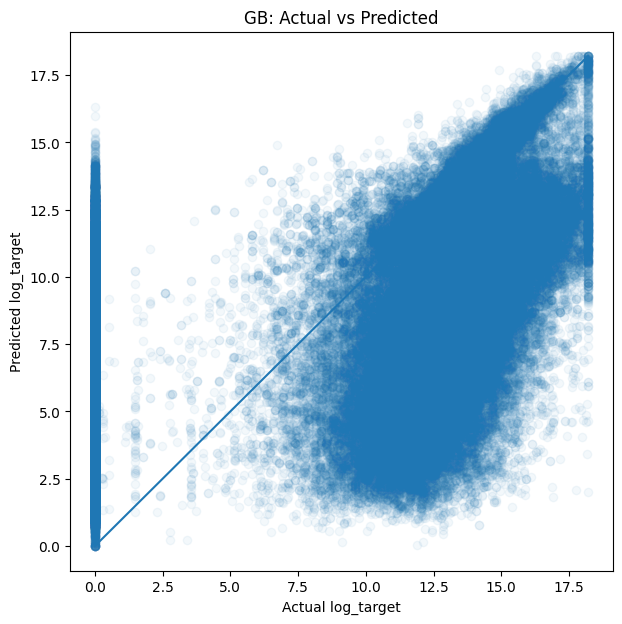

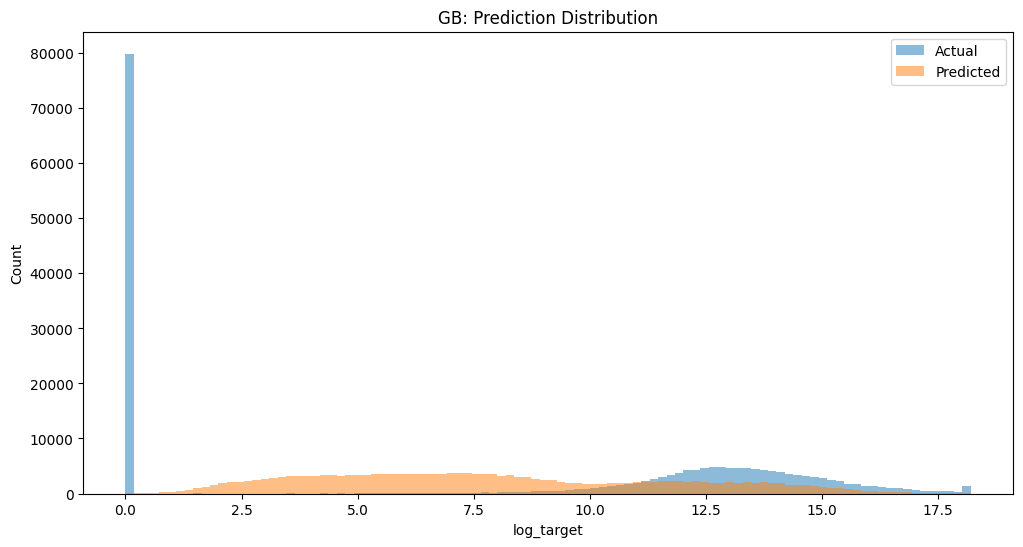

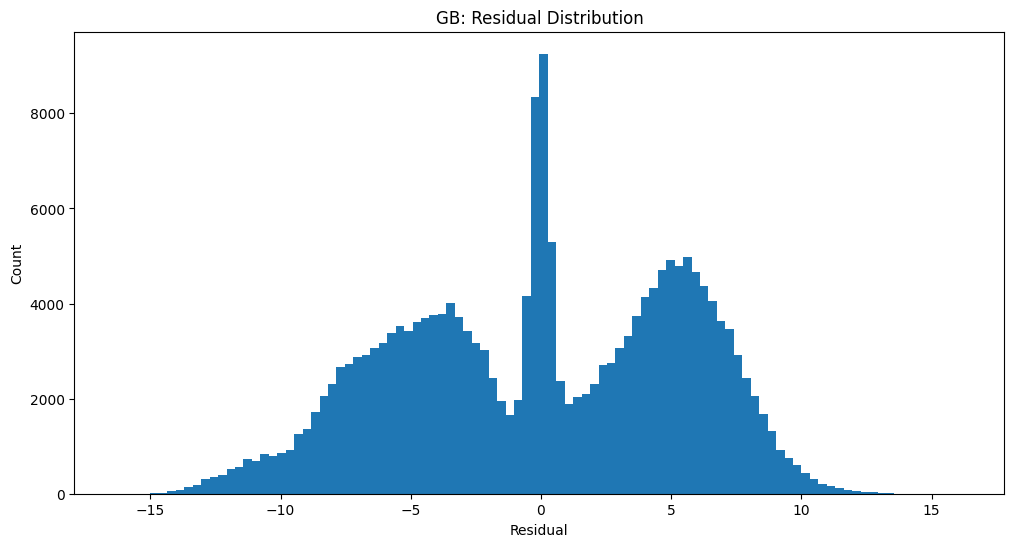

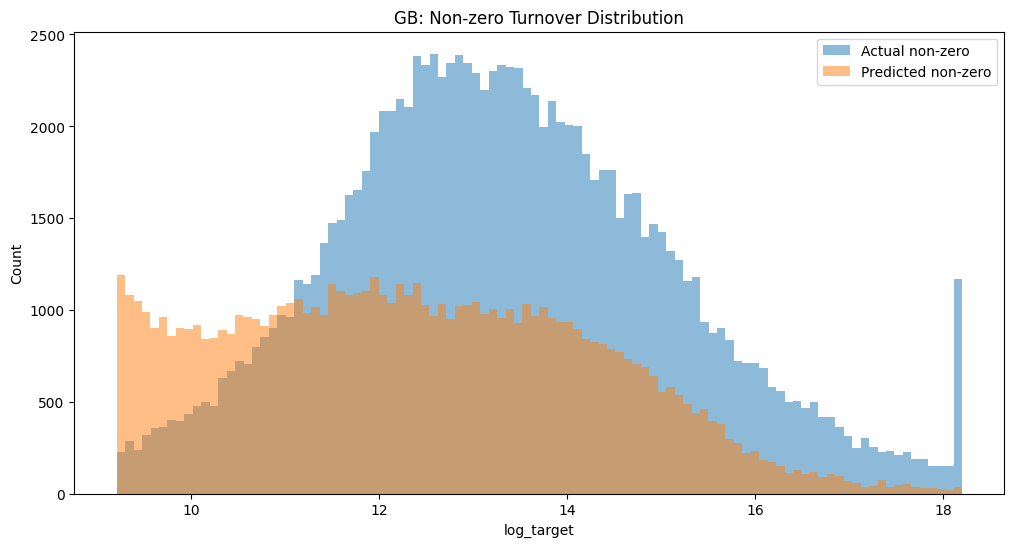

In [67]:
plot_actual_vs_predicted(
    y_true_log,
    y_pred_log,
    model_name="GB"
)

plot_prediction_distribution(
    y_true_log,
    y_pred_log,
    model_name="GB"
)

plot_residual_distribution(
    y_true_log,
    y_pred_log,
    model_name="GB"
)

plot_nonzero_distribution(
    y_true_log,
    y_pred_log,
    model_name="GB",
    min_turnover=10000
)

Выводы:

CatBoost importance показал более "чистые" значение важности признаков. Видно, что для ip_flg, transaction_cnt абсолютные значения весов в модели выше, чем в RandomForest, что свидетельствует о том, что модель более четко уловила взаимосвязи.

Графики распределений статистически ($\alpha = 0.1$) не отличаются от графиков случайного леса.